In [361]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [362]:
#plots theme 
plt.style.use ("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:"%.4f" % x)

In [363]:
#load the data
df=pd.read_csv("/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [364]:
print(f"dataset shape:{df.shape}\n")
df.dtypes


dataset shape:(7043, 21)



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [365]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [367]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.0000,7043.0000,7043.0000
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500


In [368]:
df.describe(include=object)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [369]:
#churn distribution
print(f"{df["Churn"].value_counts()}")
print(f"churn rate:{df["Churn"].value_counts(normalize=True)["Yes"]*100:.2f}%")


Churn
No     5174
Yes    1869
Name: count, dtype: int64
churn rate:26.54%


In [370]:
num_cols=df.select_dtypes(include=np.number).columns.tolist()
print(f"number of num features as presented in the dataset:{len(num_cols)}")

number of num features as presented in the dataset:3


In [371]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [372]:
cat_cols=df.select_dtypes(include=[object]).columns.tolist()
print(f"number of cat features as presented in the dataset:{len(cat_cols)}")


number of cat features as presented in the dataset:18


In [373]:
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [374]:
#check for missing values
print(f"missing values for each single feature:\n{df.isnull().sum()}")

missing values for each single feature:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [375]:
# TotalCharges is considerd to be cat feature because has spaces 
#fix
df["TotalCharges"]=pd.to_numeric(df['TotalCharges'],errors="coerce")
print(f"TotalCharges new type:{df["TotalCharges"].dtype}")

TotalCharges new type:float64


In [376]:
print(f"TotalCharges missing values:{df["TotalCharges"].isnull().sum()}")
df[df["TotalCharges"].isnull()]

TotalCharges missing values:11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.5500,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.2500,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.8500,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.7500,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.0500,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.8500,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.3500,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.0000,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.7000,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.3500,NaN,No


In [377]:
# These are new customers (tenure=0) — fill with 0
df["TotalCharges"]=df["TotalCharges"].fillna(0)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [378]:
# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['Churn'].value_counts().to_dict()

{0: 5174, 1: 1869}

In [379]:
cat_cols.remove("Churn")# the target (cat -->num 0/1)
cat_cols.remove("TotalCharges")# the fixed num feature
cat_cols.remove("customerID")#non informative feature

In [380]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

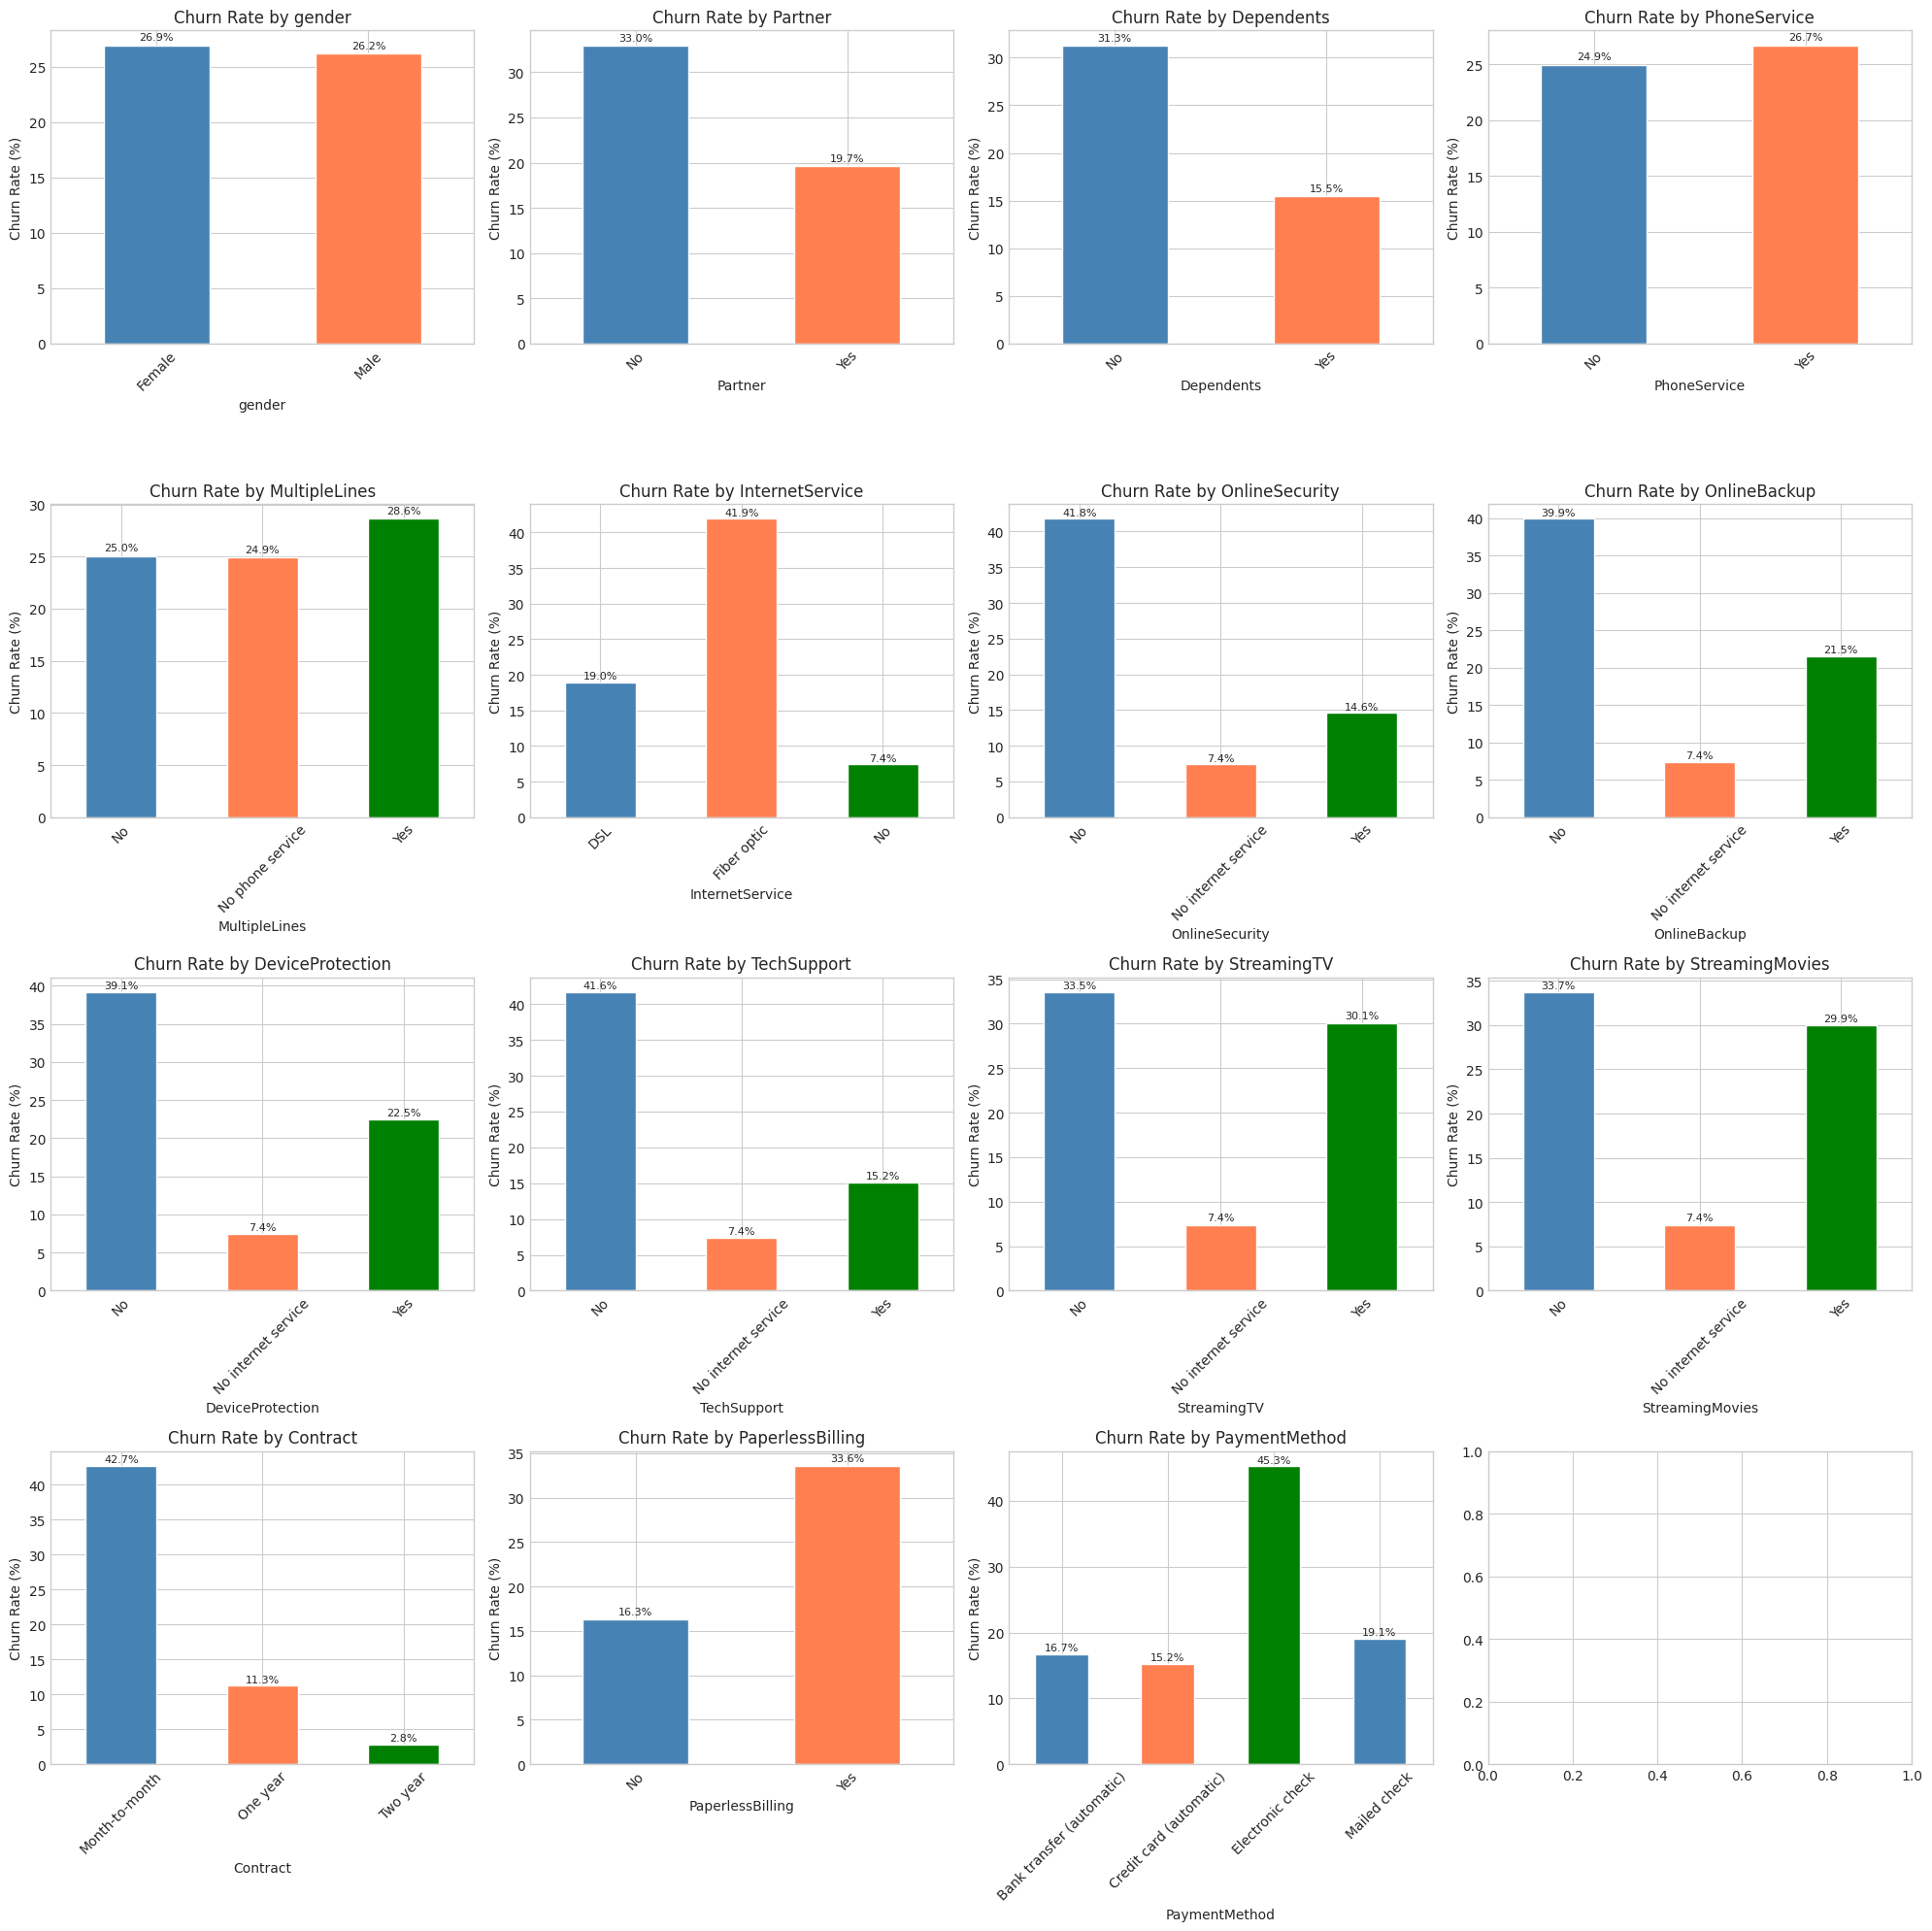

In [381]:
fig,axes=plt.subplots(4,4,figsize=(20,20))
axes=axes.flatten()
# target group by all the cat features
for i,col in enumerate(cat_cols):
    #rate of churn for each catagory in each cat feature
    churn_rate=df.groupby(col)["Churn"].mean()*100
    churn_rate.plot(kind='bar', ax=axes[i],
                    color=['steelblue', 'coral', 'green'][:len(churn_rate)],
                    edgecolor='white')
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis="x",rotation=45)
    for j,v in enumerate(churn_rate.values):
        axes[i].text(j,v+0.5,f"{v:.1f}%", ha='center', fontsize=8)
        
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/results/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()        
    


In [382]:
num_cols.append('TotalCharges')# fixed feature
num_cols.remove("SeniorCitizen")#it is a cat feature

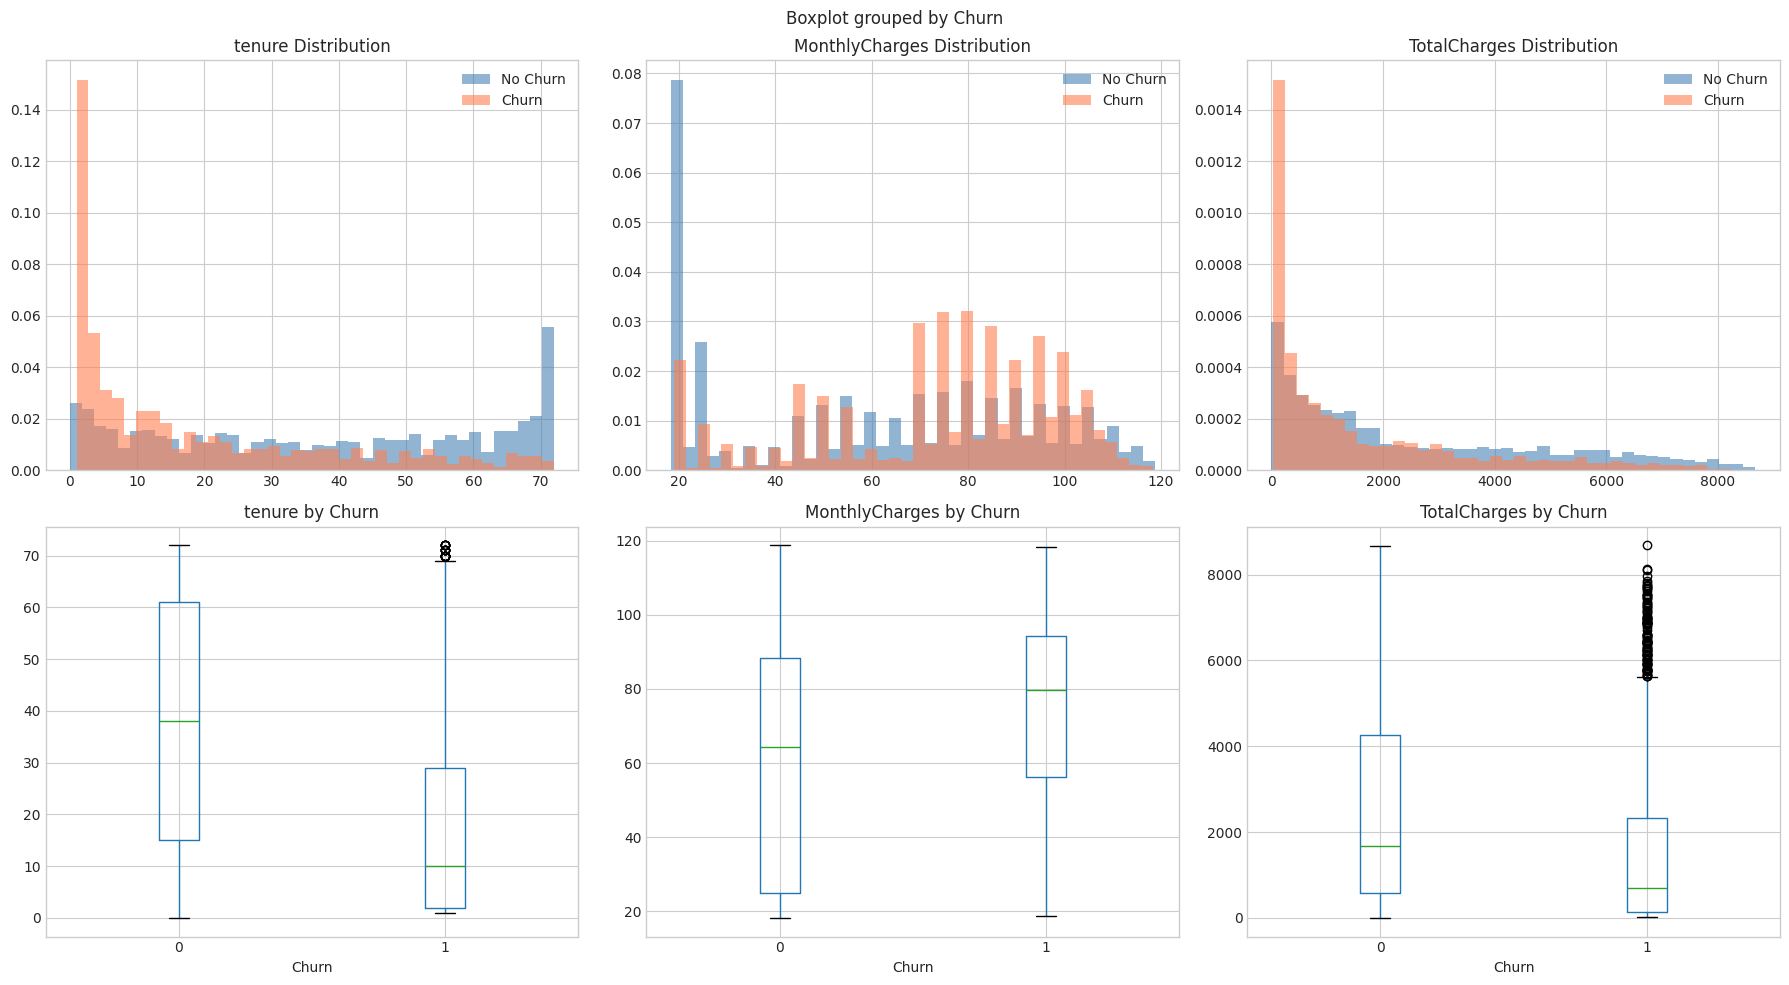

In [383]:
fig,axes=plt.subplots(2,3,figsize=(18,10))

for i,col in enumerate(num_cols):
    # Distribution by churn
    axes[0,i].hist(df[df["Churn"]==0][col],
                   bins=40, alpha=0.6,
                   color='steelblue', label='No Churn', density=True)
    axes[0, i].hist(df[df['Churn']==1][col],
                    bins=40, alpha=0.6,
                    color='coral', label='Churn', density=True)
    
    axes[0, i].set_title(f'{col} Distribution')
    axes[0, i].legend()
    
    df.boxplot(column=col,by="Churn",ax=axes[1 ,i])
    axes[1, i].set_title(f'{col} by Churn')
    
    
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/results/numerical_analysis.png', dpi=150, bbox_inches='tight')    
plt.show()    
    

In [384]:
# Statistical test
for col in num_cols:
    churn_vals=df[df["Churn"]==1][col]
    no_churn_vals=df[df["Churn"]==0][col]
    stat, p = stats.mannwhitneyu(churn_vals, no_churn_vals)
    print(f"{col}: p-value={p:.2e} {'Significant' if p<0.05 else 'Not significant'}")


tenure: p-value=2.42e-208 Significant
MonthlyCharges: p-value=3.31e-54 Significant
TotalCharges: p-value=5.69e-83 Significant


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


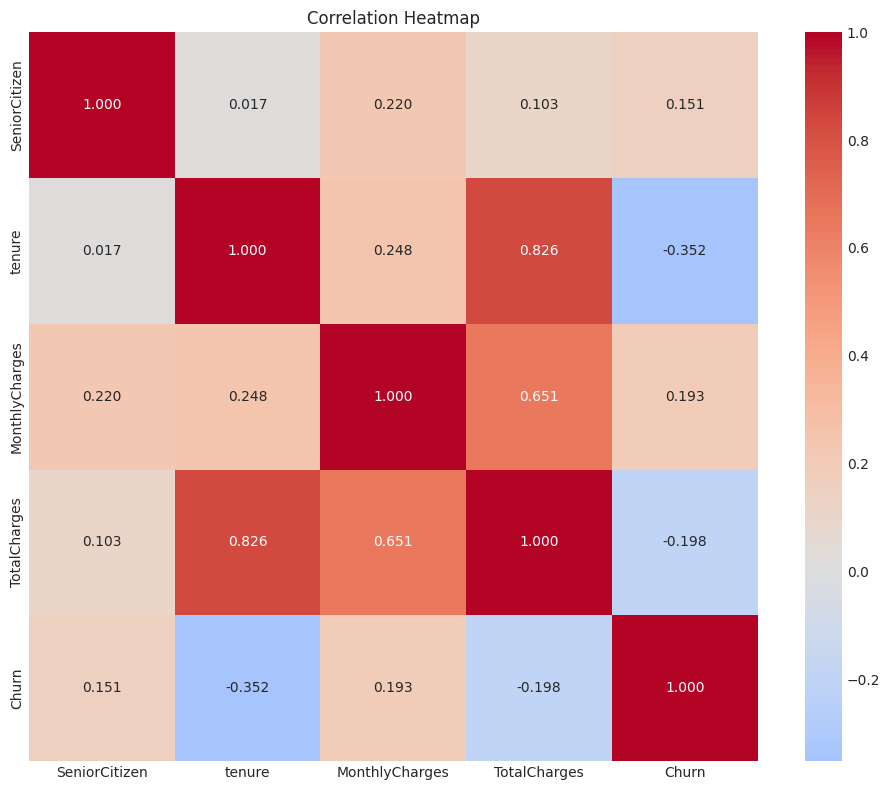

In [385]:
#Correlation Analysis 

num_features=df.select_dtypes(include=np.number).columns.tolist()
print(num_features)
corr = df[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [386]:
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.0000,0.0166,0.2202,0.1030,0.1509
tenure,0.0166,1.0000,0.2479,0.8262,-0.3522
MonthlyCharges,0.2202,0.2479,1.0000,0.6512,0.1934
TotalCharges,0.1030,0.8262,0.6512,1.0000,-0.1983
Churn,0.1509,-0.3522,0.1934,-0.1983,1.0000


In [387]:
print(corr['Churn'].drop('Churn').sort_values(ascending=False))

MonthlyCharges    0.1934
SeniorCitizen     0.1509
TotalCharges     -0.1983
tenure           -0.3522
Name: Churn, dtype: float64


In [388]:
# feature engineering
# continous to discrete feture
#feature1 group tenure
df["tenure_group"]=pd.cut(
    df["tenure"],
    bins=[0,12,24,48,60,72],
    labels=['0-1y','1-2yr', '2-4yr', '4-5yr', '5-6yr']
)
#feature2 charges per months in the firm
df["charges_per_tenure"]=np.where(
    df["tenure"]>0,#cond
    df["TotalCharges"]/df["tenure"],#if true
    df["MonthlyCharges"]#if false
)
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
#feature3 number of services the customer is in
df["num_services"]=df[service_cols].apply(
    lambda x:(x=="Yes").sum(),axis=1
)
#feature4 see if the customer has a high value
df["high_value"]=(
    (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)) &
    (df['tenure'] > 24)
).astype(int)
#faeture5 see is there a risk of churn
df["high_risk"]=(
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)



In [389]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charges_per_tenure,num_services,high_value,high_risk
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,0,0-1y,29.8500,1,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5000,0,2-4yr,55.5735,3,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,1,0-1y,54.0750,3,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.7500,0,2-4yr,40.9056,3,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.6500,1,0-1y,75.8250,1,0,1


In [390]:
df.shape

(7043, 26)

In [391]:
print(f"\nHigh risk churn rate: {df[df['high_risk']==1]['Churn'].mean()*100:.1f}%")
print(f"Low risk churn rate:  {df[df['high_risk']==0]['Churn'].mean()*100:.1f}%")


High risk churn rate: 52.8%
Low risk churn rate:  15.8%


In [392]:
#full preprocessing pipeline
# Drop ID column -->non representive feature
df=df.drop('customerID', axis=1)
# Encode categorical features 0 --> num_classes-1
cat_features = df.select_dtypes(include=['object', 'category']).columns
le = LabelEncoder()
for col in cat_features:
    df[col]=le.fit_transform(df[col].astype(str))
    
print(f"Shape after encoding: {df.shape}")
X=df.drop("Churn",axis=1)
y=df["Churn"]
print(f"\nFeatures: {X.shape[1]}")
print(f"Class balance: {y.value_counts(normalize=True).to_dict()}")

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain: {X_train.shape}, churn_rate={y_train.mean():.4f}")
print(f"Test:  {X_test.shape},  churn_rate={y_test.mean():.4f}")
# Scale numerical features
scaler = StandardScaler()
num_cols=X.select_dtypes(include=np.number).columns.tolist()
print(f"{num_cols}")
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

Shape after encoding: (7043, 25)

Features: 24
Class balance: {0: 0.7346301292063041, 1: 0.2653698707936959}

Train: (5634, 24), churn_rate=0.2654
Test:  (1409, 24),  churn_rate=0.2654
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'charges_per_tenure', 'num_services', 'high_value', 'high_risk']


In [ ]:
# Save data 
X_train_scaled.to_csv('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/X_train.csv', index=False)
X_test_scaled.to_csv('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/X_test.csv', index=False)
y_train.to_csv('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/y_train.csv', index=False)
y_test.to_csv('/home/hossamhamdy/AI_Portfolio/project_03_customer_churn_prediction/data/y_test.csv', index=False)